# Diet Analysis

Analyze your eating patterns: vegetarianism, meat consumption, streaks, and diet diversity.

In [1]:
import sys
sys.path.insert(0, '../scripts')
from load_data import load_nutrition, top_foods
from vegetarian_analysis import vegetarian_days_summary, vegetarian_days_recent, is_vegetarian_day, is_complete_day, top_meats
from streaks import longest_vegetarian_streak, all_vegetarian_streaks
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
nutrition = load_nutrition()
nutrition['date'] = nutrition['Date'].dt.date
print(f"Loaded {len(nutrition)} food entries across {len(nutrition['date'].unique())} days")

Loaded 2767 food entries across 182 days


## Vegetarian Days Overview

In [3]:
# Overall vegetarian days summary
summary = vegetarian_days_summary(nutrition)
print(f"Vegetarian days: {summary['vegetarian_days']} out of {summary['total_complete_days']} ({summary['percentage']:.1f}%)")

Vegetarian days: 46 out of 178 (25.8%)


In [4]:
# Last 30 days
recent_30 = vegetarian_days_recent(nutrition, days=30)
print(f"Last 30 days: {recent_30['vegetarian_days']} vegetarian days out of {recent_30['total_complete_days']} ({recent_30['percentage']:.1f}%)")

Last 30 days: 8 vegetarian days out of 29 (27.6%)


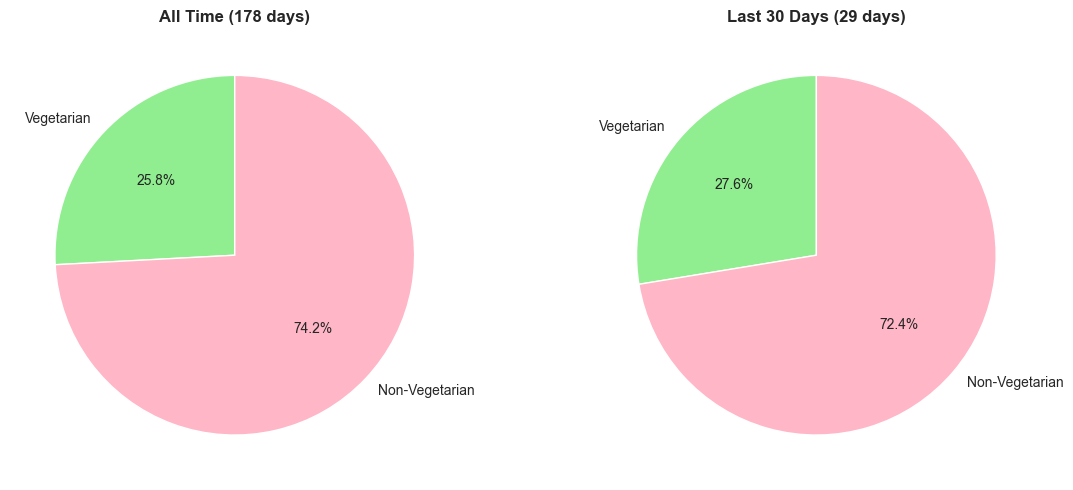

In [5]:
# Vegetarian vs non-vegetarian pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Overall
labels = ['Vegetarian', 'Non-Vegetarian']
sizes = [summary['vegetarian_days'], summary['total_complete_days'] - summary['vegetarian_days']]
colors = ['#90EE90', '#FFB6C6']
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title(f'All Time ({summary["total_complete_days"]} days)', fontsize=12, fontweight='bold')

# Last 30 days
sizes_30 = [recent_30['vegetarian_days'], recent_30['total_complete_days'] - recent_30['vegetarian_days']]
ax2.pie(sizes_30, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title(f'Last 30 Days ({recent_30["total_complete_days"]} days)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Vegetarian Streaks

In [6]:
# Longest vegetarian streak
longest = longest_vegetarian_streak(nutrition)
print(f"Longest vegetarian streak: {longest['length']} days")
if longest['length'] > 0:
    print(f"From {longest['start_date']} to {longest['end_date']}")

Longest vegetarian streak: 4 days
From 2025-12-19 to 2025-12-22


In [7]:
# All streaks (2+ days)
all_streaks = all_vegetarian_streaks(nutrition)
print(f"All vegetarian streaks (2+ days):")
for streak in all_streaks:
    print(f"  {streak['length']} days: {streak['start_date']} to {streak['end_date']}")

All vegetarian streaks (2+ days):
  4 days: 2025-12-19 to 2025-12-22
  4 days: 2026-01-15 to 2026-01-21
  4 days: 2026-02-13 to 2026-02-16
  3 days: 2026-04-05 to 2026-04-07
  2 days: 2026-01-09 to 2026-01-12
  2 days: 2026-01-30 to 2026-01-31
  2 days: 2026-03-21 to 2026-03-22


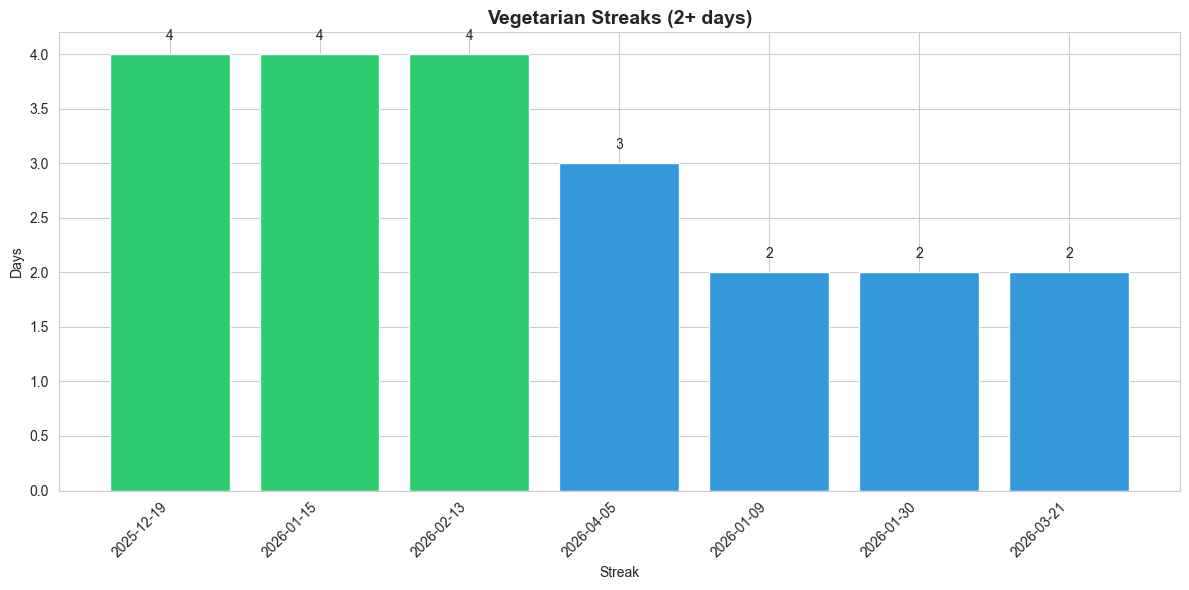

In [8]:
# Visualize streaks as bar chart
if all_streaks:
    streak_lengths = [s['length'] for s in all_streaks]
    streak_labels = [f"{s['start_date']}" for s in all_streaks]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors_list = ['#2ecc71' if l == max(streak_lengths) else '#3498db' for l in streak_lengths]
    ax.bar(range(len(streak_lengths)), streak_lengths, color=colors_list)
    ax.set_xlabel('Streak')
    ax.set_ylabel('Days')
    ax.set_title('Vegetarian Streaks (2+ days)', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(streak_labels)))
    ax.set_xticklabels(streak_labels, rotation=45, ha='right')
    
    for i, v in enumerate(streak_lengths):
        ax.text(i, v + 0.1, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

## Meat Consumption

In [9]:
# Top meats
meats = top_meats(nutrition)
meat_names = [m[0] for m in meats[:10]]
meat_counts = [m[1] for m in meats[:10]]

print("Top meats eaten (ranked by frequency):")
for i, (meat, count) in enumerate(meats, 1):
    print(f"{i}. {meat}: {count} times")

Top meats eaten (ranked by frequency):
1. chicken: 73 times
2. breast: 43 times
3. sausage: 15 times
4. trout: 14 times
5. beef: 14 times
6. salmon: 9 times
7. pork: 8 times
8. eel: 7 times
9. burger: 4 times
10. oyster: 4 times
11. cod: 4 times
12. meat: 3 times
13. sardine: 2 times
14. ham: 2 times
15. tuna: 2 times
16. turkey: 2 times
17. mackerel: 1 times
18. octopus: 1 times
19. crab: 1 times
20. duck: 1 times


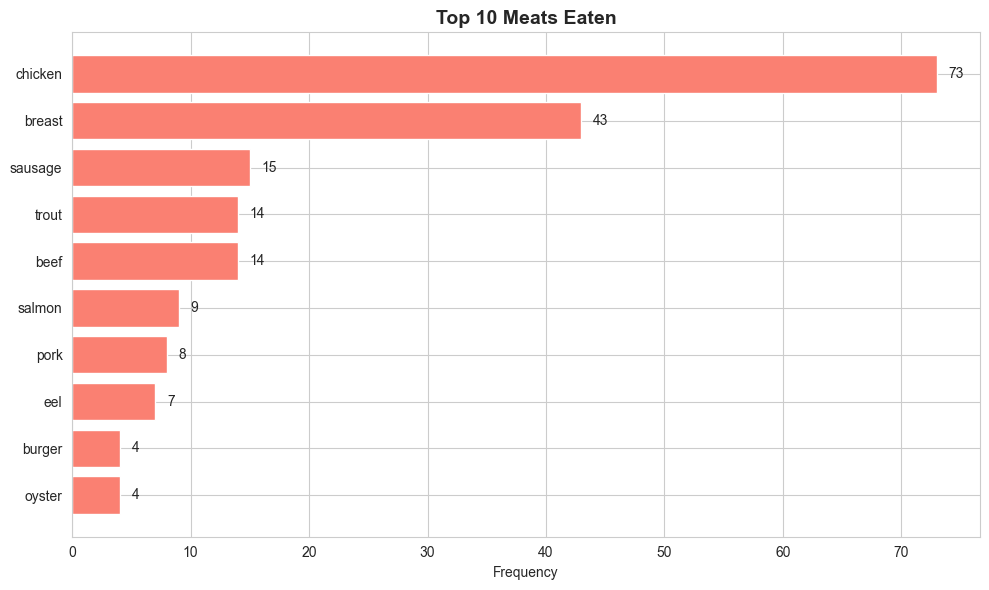

In [10]:
# Top meats bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(meat_names, meat_counts, color='salmon')
ax.set_xlabel('Frequency')
ax.set_title('Top 10 Meats Eaten', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(meat_counts):
    ax.text(v + 1, i, str(v), va='center')
plt.tight_layout()
plt.show()

## Vegetarian vs Meat Days Comparison

In [11]:
# Compare vegetarian vs meat day food counts
veggie_food_counts = []
meat_food_counts = []

for date in sorted(nutrition['date'].unique()):
    if is_complete_day(nutrition, date):
        day_foods = len(nutrition[nutrition['date'] == date])
        if is_vegetarian_day(nutrition, date):
            veggie_food_counts.append(day_foods)
        else:
            meat_food_counts.append(day_foods)

if veggie_food_counts and meat_food_counts:
    print(f"Vegetarian days: avg {sum(veggie_food_counts)/len(veggie_food_counts):.1f} foods/day")
    print(f"Meat days: avg {sum(meat_food_counts)/len(meat_food_counts):.1f} foods/day")

Vegetarian days: avg 12.3 foods/day
Meat days: avg 16.5 foods/day


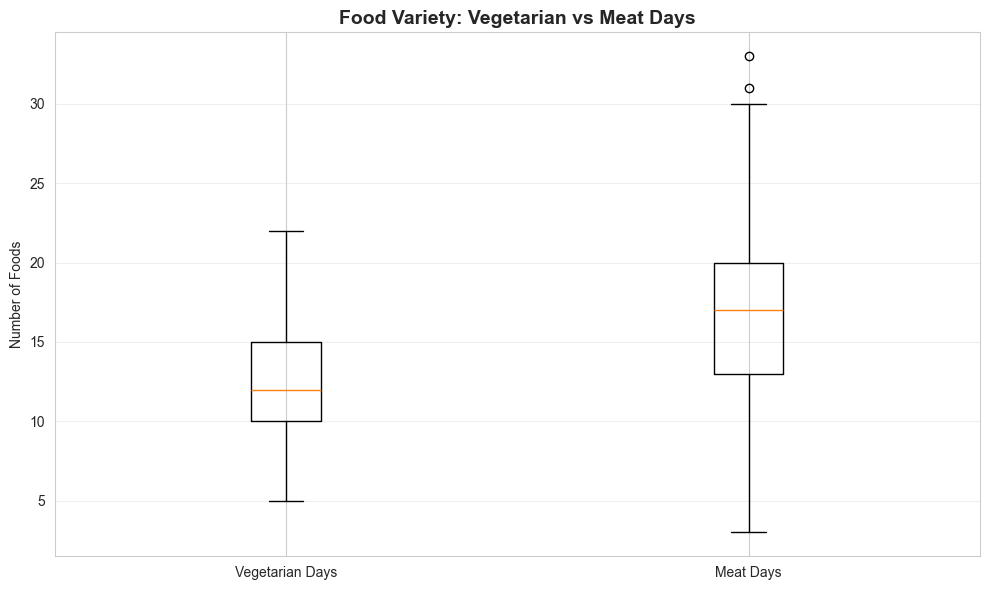

In [12]:
# Box plot of food variety
if veggie_food_counts and meat_food_counts:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot([veggie_food_counts, meat_food_counts], tick_labels=['Vegetarian Days', 'Meat Days'])
    ax.set_ylabel('Number of Foods')
    ax.set_title('Food Variety: Vegetarian vs Meat Days', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()